# Step 3. Find shifts. Currently they are adjusted from the ones Peter got.

In [40]:
import numpy as np
import cupy as cp
import h5py
import matplotlib.pyplot as plt
import scipy
from holotomocupy.utils import *

## Init

In [41]:
ntheta = 1800
ids = np.arange(0, 1800, 1800 / ntheta).astype('int')


path_out = '/data2/vnikitin/atomium_rec/20250607/AtomiumL1'
file_out = f'data.h5'


with h5py.File(f'{path_out}/data.h5') as fid:
    detector_pixelsize = fid['/exchange/detector_pixelsize'][0]    
    focustodetectordistance = fid['/exchange/focusdetectordistance'][0]    
    z1 = fid['/exchange/z1'][:] 
    theta = -fid['/exchange/theta'][ids, 0] / 180 * np.pi
    energy = fid['/exchange/energy'][0] 
    shifts = fid['/exchange/shifts'][ids]    
    shape = np.array(fid[f'/exchange/data0'].shape)

wavelength = 1.24e-09 / energy
z2 = focustodetectordistance - z1
magnifications = focustodetectordistance / z1
norm_magnifications = magnifications / magnifications[0]
distances = (z1 * z2) / focustodetectordistance * norm_magnifications**2
voxelsize = detector_pixelsize / magnifications[0]

n = shape[1]
ndist=len(z1)
print(f'{energy=}')
print(f'{z1=}')
print(f'{focustodetectordistance=}')
print(f'{detector_pixelsize=}')
print(f'{magnifications=}')
print(f'{voxelsize=}')
print(f'{distances=}')

energy=33.35
z1=array([0.006113, 0.006375, 0.007424, 0.009602], dtype=float32)
focustodetectordistance=1.2889996
detector_pixelsize=2.9520295e-06
magnifications=array([210.86201, 202.19601, 173.626  , 134.24281], dtype=float32)
voxelsize=1.3999816e-08
distances=array([0.00608401, 0.00583278, 0.00500452, 0.00386278], dtype=float32)


### All shifts will be converted to the object pixel coordinates in the highest magnification

In [42]:
random_shifts = np.zeros([ntheta, ndist, 2], dtype='float32')
for k in range(ndist):
    random_shifts[:, k, 0] = shifts[:, k, 1] / norm_magnifications[k]
    random_shifts[:, k, 1] = shifts[:, k, 0] / norm_magnifications[k]

#### Rhapp, alignment between planes. Saved in rhapp.mat file, converted to python.

In [43]:
#save('/data2/vnikitin/brain_rec/20240515/Y350c/rhapp_python.mat','rhapp','-v7')
rhapp_shifts = scipy.io.loadmat(f'{path_out}/rhapp_python.mat')['rhapp']
rhapp_shifts = -rhapp_shifts.swapaxes(0, 2)[:1800]

### Motion shifts, alignment for a reference plane. Initially given with random shifts include, we subtract random shifts.

In [44]:
motion_shifts = np.zeros_like(rhapp_shifts)
for k in range(4):
    motion_shifts[:, k] = np.loadtxt('/data2/vnikitin/atomium/20250607/AtomiumL1/AtomiumL1_HT_014nm_1_/correct_motion.txt')[:1800][:, ::-1] / norm_magnifications[0]
    motion_shifts[:, k] -= random_shifts[:, 0]

### Correct 3D shifts, alignment before tomography reconstruction

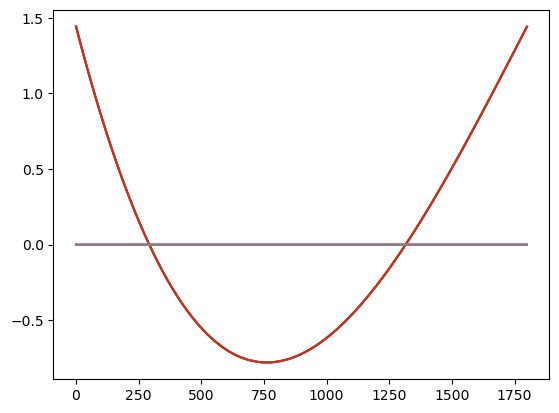

In [45]:
correct3d_shifts = np.loadtxt(f'/data2/vnikitin/brain_rec/20251115/Y350a/correct_correct3D_1234.txt')[:4500][:, ::-1]
correct3d_shifts = np.tile(correct3d_shifts[:, np.newaxis], (1, ndist, 1))

ids = np.arange(0, 4500, 4500 / ntheta).astype('int')
correct3d_shifts = correct3d_shifts[ids]

correct3d_shifts*=20/14

correct3d_shifts[...,1] = 0
plt.plot(correct3d_shifts[...,0]/4)
plt.plot(correct3d_shifts[...,1]/4)
# ss

### Visualization

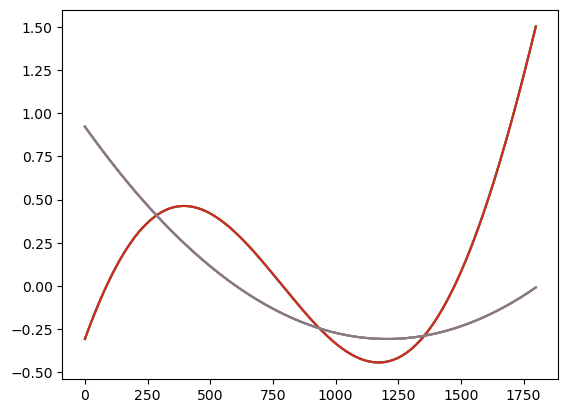

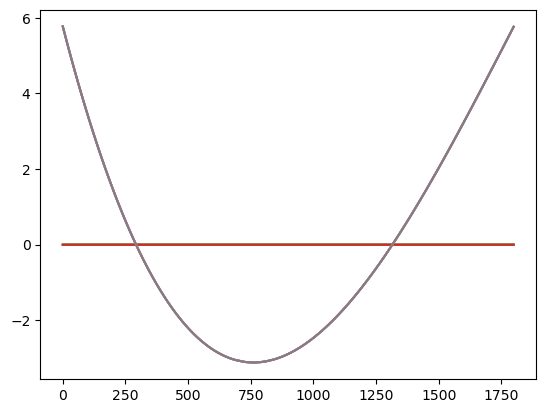

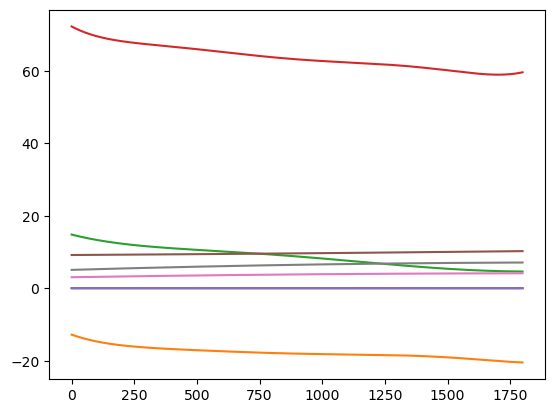

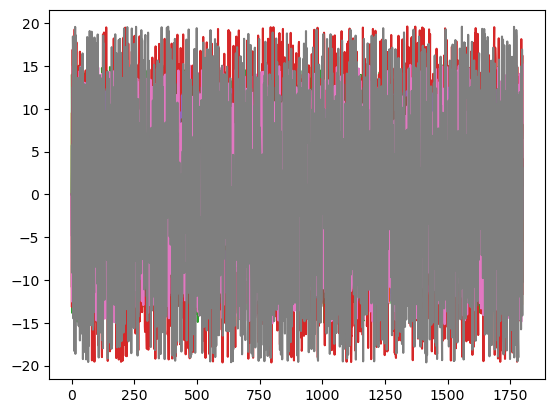

In [46]:
plt.plot(motion_shifts[:,:,1])
plt.plot(motion_shifts[:,:,0])
plt.show()

plt.plot(correct3d_shifts[:,:,1])
plt.plot(correct3d_shifts[:,:,0])
plt.show()

plt.plot(rhapp_shifts[:,:,1])
plt.plot(rhapp_shifts[:,:,0])
plt.show()


plt.plot(random_shifts[:,:,1])
plt.plot(random_shifts[:,:,0])
plt.show()


#### Final shifts is the sum of all.

In [ ]:
shifts_final = rhapp_shifts + correct3d_shifts + motion_shifts + random_shifts

array([ 6.69108163, -0.308011  ])

## Save to file

In [48]:
print(f'{path_out}/data.h5')
with h5py.File(f'{path_out}/data.h5', 'a') as fid:
    if f'/exchange/cshifts_final' in fid:
            del fid[f'/exchange/cshifts_final']
    fid.create_dataset(f'/exchange/cshifts_final', data=shifts_final.astype('float32'))

/data2/vnikitin/atomium_rec/20250607/AtomiumL1/data.h5
